# Retrieval Products Analysis
### Quality check for IWV, IWP, LWP
Uses comparison-env as environment

What this notebook can:
1. Compare IWV with dropsondes IWV
2. Show Condensate Loads on a map
3. Compate Condensate Loads with radar 

In [1]:
#%% Loading packages
import numpy as np

import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import fsspec
from matplotlib import cm
from matplotlib.colors import Normalize 
from scipy.interpolate import interpn
import glob
from functools import partial
import sys
#sys.path.append('/home/u/u301238/master_thesis/')
sys.path.append('/home/u/u301032/orcestra/NN_IWP_retrieval/')
#import src
import src_comparison_halo_pamtra as chp

In [2]:
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

In [3]:
pd.Timedelta(minutes=5)

Timedelta('0 days 00:05:00')

## Data to Load
Reading in the following data sets:
* Halo Data ( Radar)
* IWV, IWP and LWP products



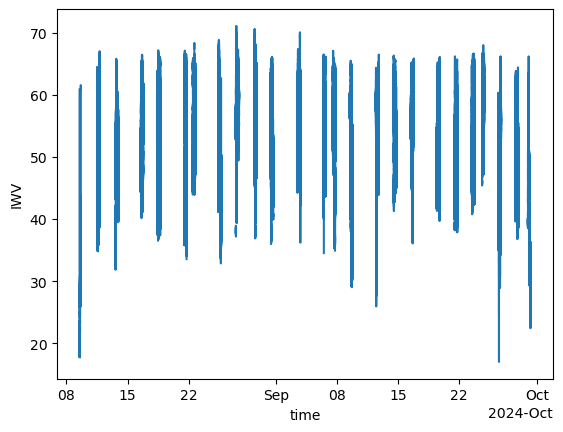

In [3]:
ds_HAMP=xr.open_dataset("/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_v1-1.nc")
ds_HAMP
#ds_HAMP.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_v1.nc')

IWV=ds_HAMP.IWV.where(np.all(ds_HAMP.mask_amplifier_fault,axis=1))
LWP=ds_HAMP.LWP.where(np.all(ds_HAMP.mask_amplifier_fault,axis=1))
IWP=ds_HAMP.IWP.where(np.all(ds_HAMP.mask_amplifier_fault,axis=1))
ds_HAMP['IWV']= IWV#(('time',), IWV)
ds_HAMP['IWP']= IWP#(('time',), IWP)
ds_HAMP['LWP']= LWP#(('time',), LWP)
ds_HAMP.IWV.plot()

In [5]:
#ds_HAMP.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_v1-3.nc')

In [4]:

ds_radar,ds_halo,ds_halo_altitude,ds_halo_iwv_KW,ds_sondes=chp.reading_halo_data()

ds_hamp=xr.open_dataset('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_v1-3.nc')
da_masked = ds_hamp.TBs.where(ds_hamp.mask_sea_land, drop=True)

# use amplifier fault mask and land sea mask
da_masked = da_masked.where(ds_hamp.mask_amplifier_fault, drop=True)
# add filtered data array to variable
ds_hamp['TBs']=  da_masked
excluded_frequencies = ds_hamp.frequency.where(ds_hamp.frequency!=184.81, drop=True)
# Step 2: Filter the dataset to exclude the specified frequency
ds_hamp = ds_hamp.sel(frequency=excluded_frequencies)
#ds_radar = chp.only_tropics(xr.open_dataset("ipfs://bafybeigmd3dovwm45ylfqxnn2jphsrdjl2jt3dfytv7grkyhleaq42jthe", engine="zarr") )#MIRA Cloud Radar Moments



## 1. Compare IWV with dropsondes IWV

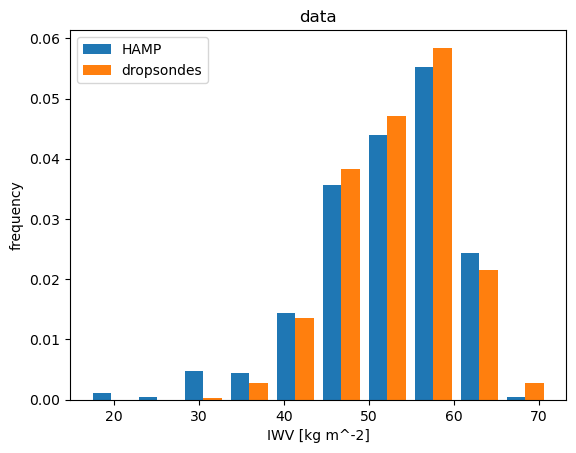

In [4]:
#%% histograms sondes vs halo
plt.hist([ds_hamp.IWV,ds_sondes.iwv],label=['HAMP','dropsondes'],density=True)
plt.title('data')
plt.legend()
plt.xlabel("IWV [kg m^-2]")
plt.ylabel("frequency")
plt.show()




In [5]:
# Convert the sonde_time to pandas Timestamps if not already
sonde_times = pd.to_datetime(ds_sondes.sonde_time.values)

# Initialize a list to hold selected datasets
selected_datasets =[]
m=np.full(len(ds_hamp['time']),False)

for t in sonde_times:
    # Define time window: t - 10 minutes to t + 10 minutes
    start_time = t - pd.Timedelta(minutes=5)
    end_time = t + pd.Timedelta(minutes=5)
    
    # Select entries in ds_hamp within this time window
    mask = (ds_hamp['time'] >= start_time) & (ds_hamp['time'] <= end_time)

    m=np.logical_or(mask,m)
    #selected = ds_hamp.sel(time=mask)
    
    # Optionally, store or process the selected subset
    #selected_datasets.append(selected)
    


ds_hamp_sondetime=ds_hamp.where(m,drop=True)
ds_hamp_sondetime

<xarray.Dataset> Size: 1GB
Dimensions:               (time: 1424734, frequency: 25)
Coordinates:
  * frequency             (frequency) float32 100B 22.24 23.04 ... 188.3 190.8
  * time                  (time) datetime64[ns] 11MB 2024-08-09T14:22:28 ... ...
Data variables: (12/14)
    AziAng                (time, frequency) float32 142MB 0.0 0.0 ... 0.0 0.0
    ElAng                 (time, frequency) float32 142MB 0.0 0.0 ... 179.9
    RF                    (time, frequency) float64 285MB 0.0 0.0 ... 0.0 0.0
    TBs                   (time, frequency) float32 142MB 183.0 181.5 ... 276.6
    lat                   (time) float64 11MB 22.58 22.58 22.58 ... 10.74 10.74
    lon                   (time) float64 11MB -19.26 -19.26 ... -56.79 -56.79
    ...                    ...
    plane_altitude        (time) float64 11MB 1.4e+04 1.4e+04 ... 1.441e+04
    plane_pitch           (time) float64 11MB 2.556 2.553 2.551 ... 2.175 2.189
    plane_roll            (time) float64 11MB -0.009832 0.003104 ... -0.02255
    IWV                   (time) float64 11MB 31.52 31.67 31.71 ... 46.45 46.85
    IWP                   (time) float64 11MB 0.3306 0.3414 ... 0.2371 0.1867
    LWP                   (time) float64 11MB 0.04769 0.1938 ... 0.875 0.6218
Attributes: (12/16)
    Host-PC_Software_Version:     V9.45
    Radiometer_Software_Version:  V9.45
    Radiometer_System:             RPG-HATPRO
    creator_email:                jakob.deutloff@uni-hamburg.de, lukas.kluft@...
    creator_name:                 Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:                  trajectoryProfile
    ...                           ...
    platform:                     HALO
    project:                      ORCESTRA, PERCUSION
    references:                   10.5194/amt-12-1815-2019, 10.5194/essd-13-5...
    summary:                      This dataset contains measurements from the...
    title:                        Radiometer Data from the Halo Microwave Pac...
    version:                      1.0

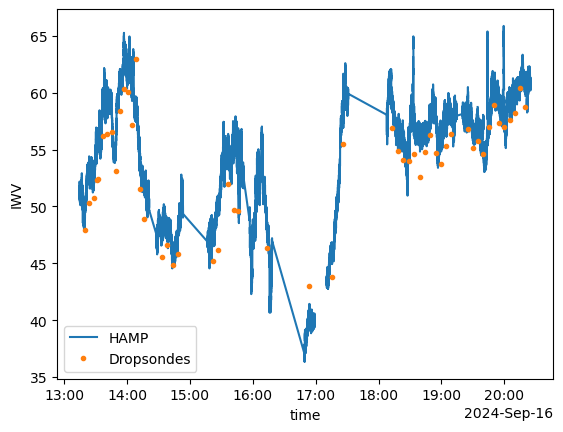

In [6]:
target_date = '2024-09-16'#'2024-09-19'#'2024-09-26'#'2024-08-11'#
target_datetime = pd.to_datetime(target_date)
ds_sondes_f = ds_sondes.where(ds_sondes['sonde_time'].dt.date == xr.DataArray(pd.to_datetime(target_date).date()), drop=True)

ds_HAMP_f=ds_hamp_sondetime.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))

#ds_iwv_kw_f=ds_iwv_kw.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))
# Now filtered_ds_sondes contains only the entries for August 9, 2024

#ds_iwv_kw_f.IWV.plot(label='kw')
ds_HAMP_f.IWV.plot(label='HAMP')
plt.plot(ds_sondes_f.sonde_time,ds_sondes_f.iwv,'.',label='Dropsondes')
plt.legend()
plt.show()

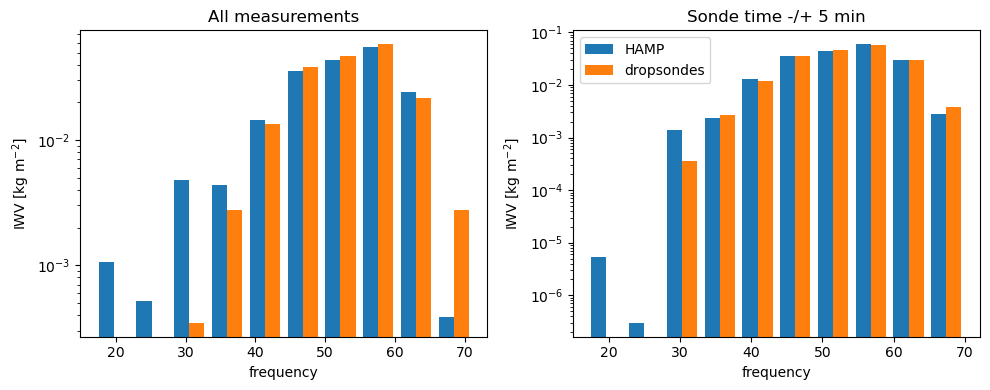

In [8]:

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot data on the first subplot
ax1.hist([ds_hamp.IWV,ds_sondes.iwv],label=['HAMP','dropsondes'],density=True,log=True)
ax1.set_title('All measurements')
ax1.set_xlabel('frequency')
ax1.set_ylabel('IWV [kg m$^{-2}$]')

# Plot data on the second subplot
ax2.hist([ds_hamp_sondetime.IWV,ds_sondes.iwv],label=['HAMP','dropsondes'],density=True,log=True)
ax2.set_title('Sonde time -/+ 5 min')
ax2.set_xlabel('frequency')
ax2.set_ylabel('IWV [kg m$^{-2}$]')
plt.legend()
# Adjust layout to prevent overlap
plt.tight_layout()

# Display the figure
plt.show()

/home/u/u301032/.conda/envs/orcestra-retrieval-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


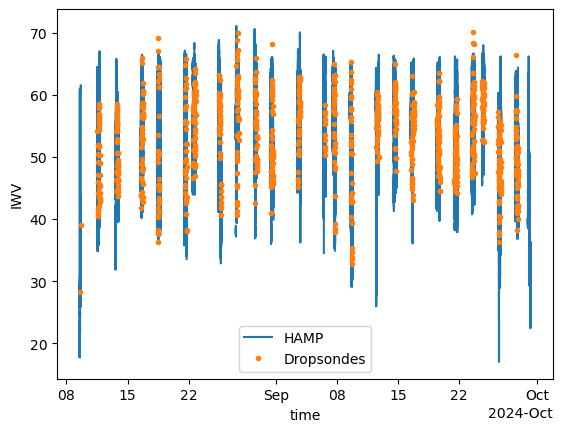

In [64]:

#ds_iwv_kw_f.IWV.plot(label='kw')
ds_hamp.IWV.plot(label='HAMP')
plt.plot(ds_sondes.sonde_time,ds_sondes.iwv,'.',label='Dropsondes')
plt.legend()
plt.show()

In [5]:
fs = fsspec.filesystem("ipns")
fs.glob("ipns://latest.orcestra-campaign.org/products/HALO/HAMP/*")
#fs.resolve('latest.orcestra-campaign.org/products/HALO/HAMP/full_radiometer.zarr')

['latest.orcestra-campaign.org/products/HALO/HAMP/full_iwv.zarr',
 'latest.orcestra-campaign.org/products/HALO/HAMP/full_radar.zarr',
 'latest.orcestra-campaign.org/products/HALO/HAMP/full_radiometer.zarr']

In [6]:
ds_halo_latest=xr.open_dataset("ipns://"+'latest.orcestra-campaign.org/products/HALO/HAMP/full_radiometer.zarr', engine="zarr")#radiometer
  
excluded_frequencies = ds_halo_latest.frequency.where(ds_halo_latest.frequency!=184.81, drop=True)
# Step 2: Filter the dataset to exclude the specified frequency
ds_halo_latest = ds_halo_latest.sel(frequency=excluded_frequencies)

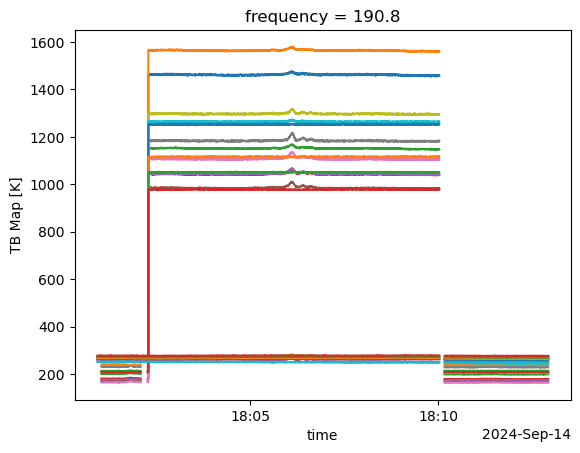

In [11]:
for freq in ds_halo_latest.frequency.values:
    
    ds_halo_latest.sel(frequency=freq,time=slice('2024-09-14T18:00:55.500000000', '2024-09-14T18:12:55.750000000')).TBs.plot()
    #ds_halo_latest.sel(time=slice('2024-09-14T18:00:55.500000000', '2024-09-14T18:12:55.750000000')).mask_amplifier_fault.plot()

## 2. Show Condensate Loads on a map

In [18]:
ds_halo
frequencies


array([ 22.24,  23.04,  23.84,  25.44,  26.24,  27.84,  31.4 ,  50.3 ,
        51.76,  52.8 ,  53.75,  54.94,  56.66,  58.  ,  90.  , 110.25,
       114.55, 116.45, 117.35, 120.15, 121.05, 122.95, 127.25, 170.81,
       175.81, 178.31, 179.81, 180.81, 181.81, 182.71, 183.91, 184.81,
       185.81, 186.81, 188.31, 190.81, 195.81])

## 3. Compare Condensate Loads with radar 

In [89]:
# Select target day
def sel_target_date(target_date,ds):
  target_datetime = pd.to_datetime(target_date)
  if 'time' in ds.coords:
     ds_filtered=ds.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))
  elif 'sonde_time' in ds.coords:
    ds_filtered = ds.where(ds['sonde_time'].dt.date == xr.DataArray(pd.to_datetime(target_date).date()), drop=True)
  else:
    print("please check dimension names for time dimension")
  return ds_filtered

target_date = '2024-08-12'#'2024-08-27'#'2024-08-09'#'2024-09-14'#'2024-08-11'#'2024-09-16'#''2024-09-26'#'2024-08-11'#2024-09-19'#

#ds_halo_f = sel_target_date(target_date,ds_halo)
#ds_halo_altitude_f = sel_target_date(target_date, ds_halo_altitude)
#ds_halo_iwv_KW_f = sel_target_date(target_date, ds_halo_iwv_KW)
#ds_sondes_f = sel_target_date(target_date, ds_sondes )
ds_hamp_f = sel_target_date(target_date, ds_hamp)
ds_radar_f = sel_target_date(target_date, ds_radar)




NameError: name 'ds_radar' is not defined

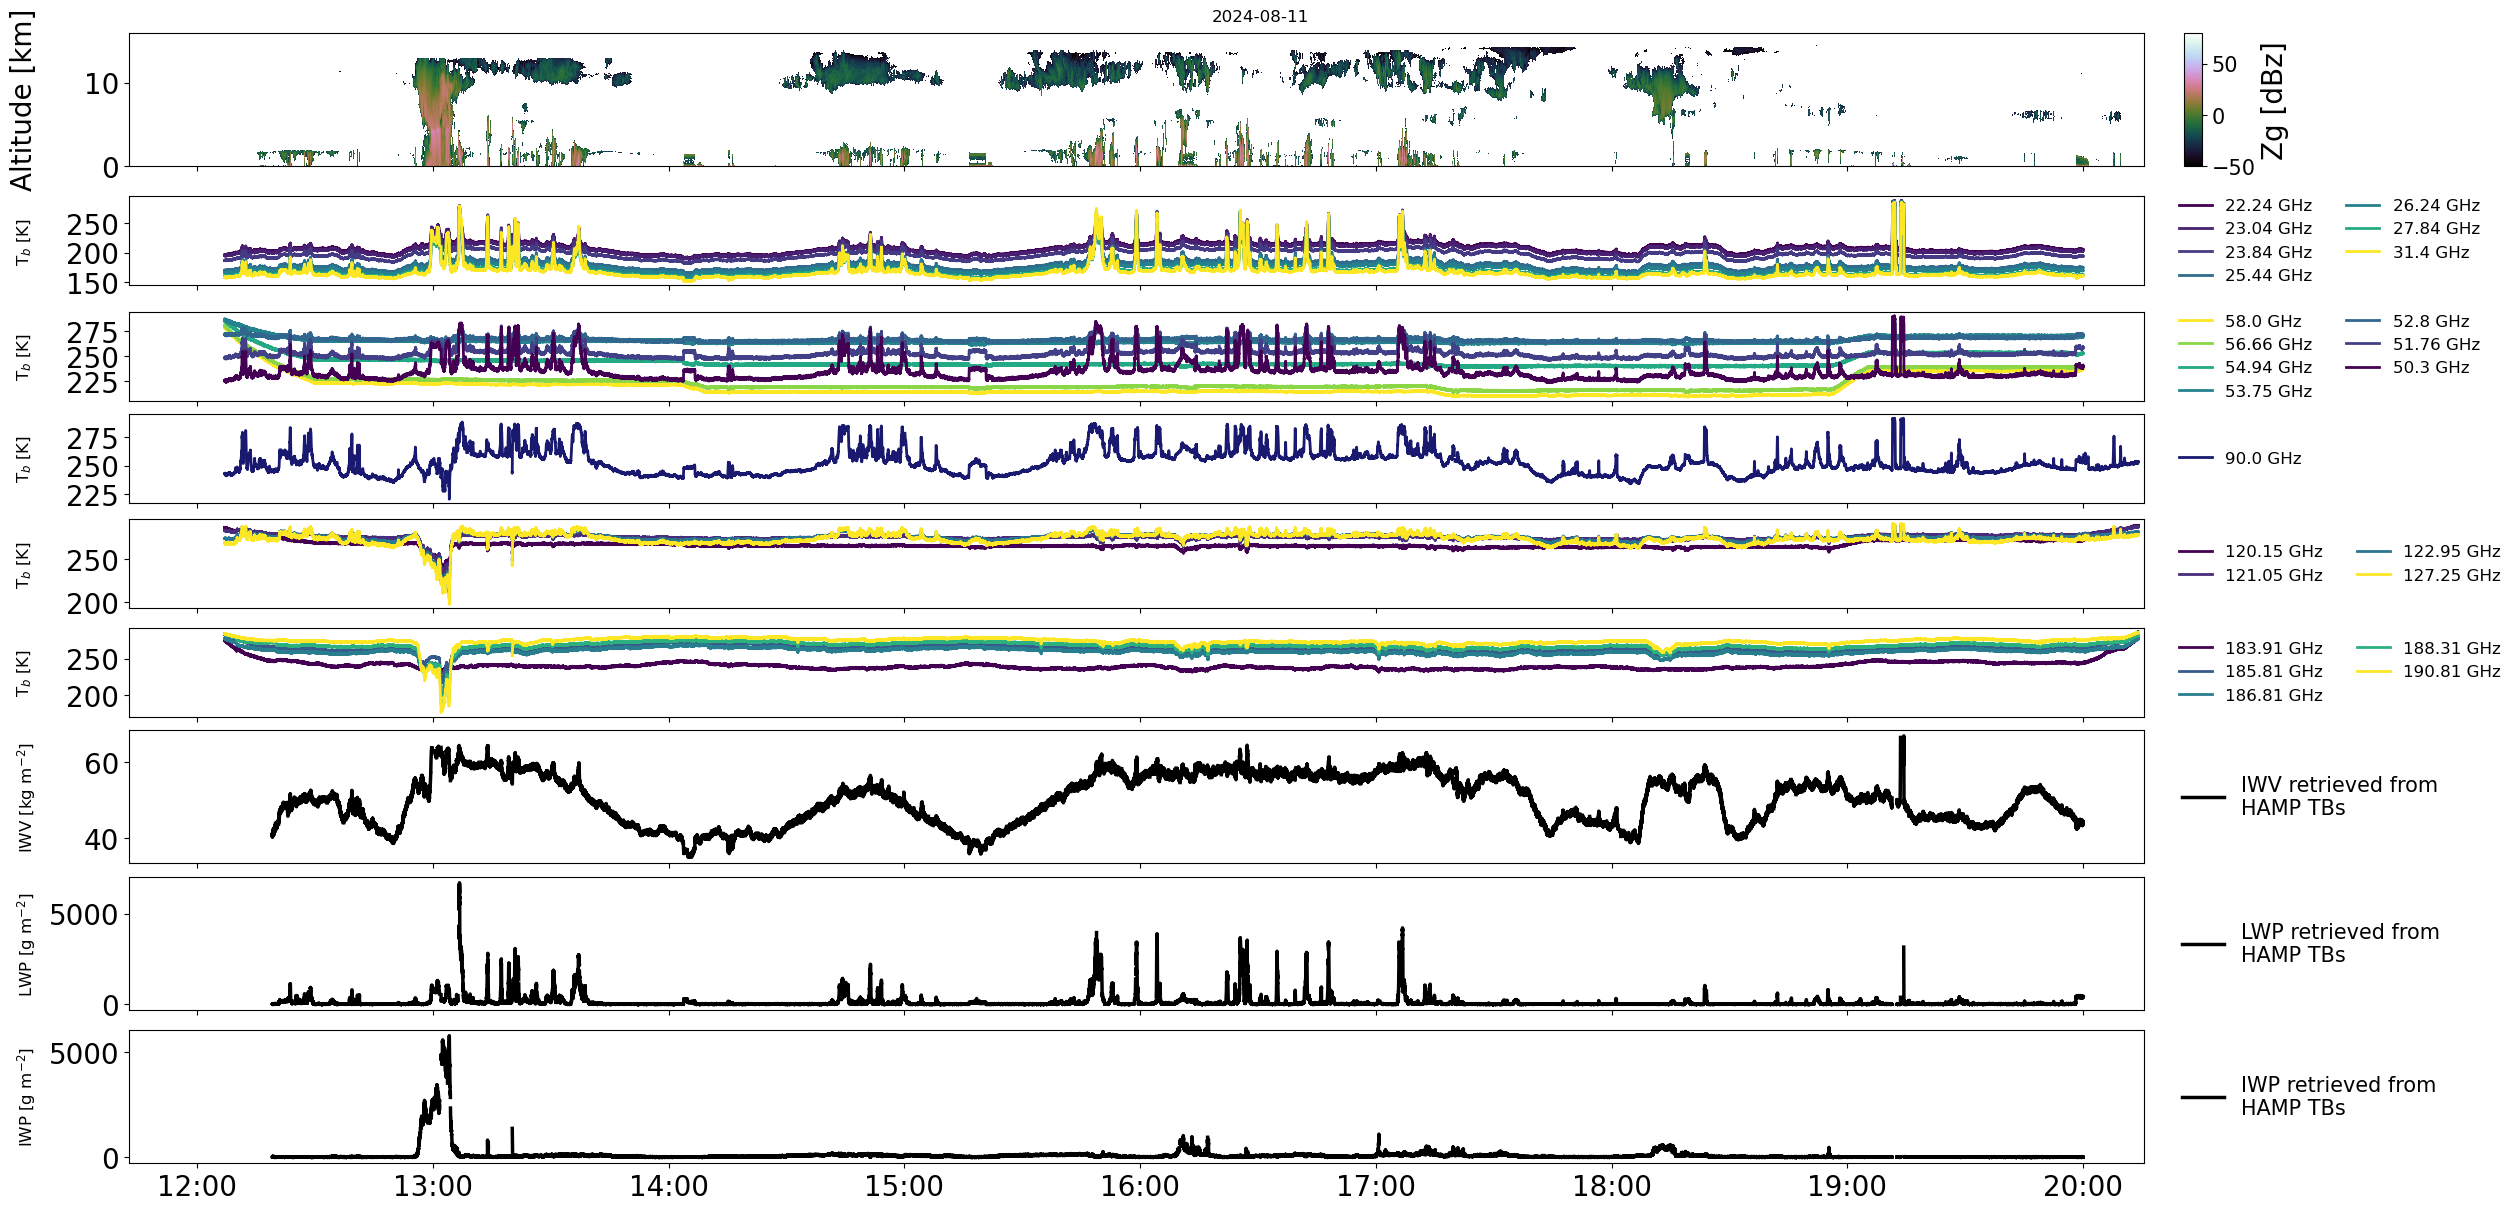

In [13]:
DATE = target_date# '2024-09-16'
radar=ds_radar_f

fig, axs = plt.subplots(nrows=9,ncols=1,
                        sharex=True,
                        figsize=(25,12),
                        gridspec_kw={'height_ratios': [1.5,1,1,1,1,1,1.5,1.5,1.5]},
                        constrained_layout=True)

fig.suptitle(f'{DATE}')

# set some global plot style settings
kwargs = dict(linewidth=2)
grid_alpha = 0.5
legend_fontsize = 12
y_axis_fontsize = 14
min_alt, max_alt = 0,16

# define array of frequenices to plot
frequencies = [
    chp.get_HAMP_freqs_of('K_band'),
    np.flip(chp.get_HAMP_freqs_of('V_band')),
    chp.get_HAMP_freqs_of('W_band'),
    chp.get_HAMP_freqs_of('F_band_1side'),
    np.delete(chp.get_HAMP_freqs_of('G_band_1side'),[1,-1])]

# settings of the frequency legend
props = dict(boxstyle='round', facecolor='white', alpha=1.)

# Plot radar reflectivities (Zg)
im = axs[0].pcolormesh(
    radar.time, radar.height/1000, 10*np.log10(radar.Zg.T), 
    vmin=-50, vmax=80, cmap='cubehelix', shading='nearest')
axs[0].set_ylim(min_alt,max_alt)
axs[0].set_ylabel('Altitude [km]',fontsize=20)
axs[0].yaxis.set_label_coords(-0.045,.5)
axs[0].tick_params(axis='y', labelsize=20)
cbar = fig.colorbar(im, ax=axs[0], pad=-0.16,aspect=7.5)
cbar.set_label('Zg [dBz]',size=20)
cbar.ax.tick_params(labelsize=15)

# Plot radiometer measurements (TBs)
row = 1
panel_labels =['b)','c)','d)','e)','f)']
for module in frequencies:
    
    #freq_ind = [np.where(chp.get_HAMP_freqs_of('NN_freqs')==freq)[0][0] for freq in frequencies[module]]
            #frequencies = ds.frequency.values
    norm = mcolors.Normalize(vmin=module.min(), vmax=module.max())
    cmap = plt.colormaps.get_cmap("viridis")

    for freq in module:
        if freq == 90.:
            color = 'midnightblue'
        else:           
            color = cmap(norm(freq))
        
        axs[row].plot(ds_hamp_f.time.values,ds_hamp_f.TBs.sel(frequency=freq),
                     #zorder=i,
                     color=color,
                     label=str(freq)+' GHz',#label=f"{freq:.2f} GHz"
                     **kwargs)

                      
        

    axs[row].set_ylabel('T$_b$ [K]',fontsize=12)
    axs[row].yaxis.set_ticks_position('left')
    axs[row].yaxis.set_label_coords(-0.047,.5)
    axs[row].tick_params(axis='y', labelsize=20)
    axs[row].legend(frameon=False, 
                   bbox_to_anchor=(1.01, 0.5), 
                   loc='center left', 
                   ncol=2, 
                   fontsize=legend_fontsize)

    row+=1

# Plot IWV retrieved from HAMP TBs 
axs[6].plot(ds_hamp_f.time.values,ds_hamp_f.IWV,color='black',linewidth=2.5,label='IWV retrieved from \nHAMP TBs')
#axs[6].fill_between(ds_hamp_f.time.values,ds_hamp_f.IWV.max(), where=ds_hamp_f.mask_sea_land==0, facecolor='red', alpha=.4,label='land == True')
axs[6].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[6].tick_params(axis='x', labelsize=20)
axs[6].tick_params(axis='y', labelsize=20)
axs[6].set_ylabel('IWV [kg m$^{-2}$]',color='black',fontsize=12)
axs[6].yaxis.set_label_coords(-0.045,.5)
axs[6].legend(frameon=False, 
              bbox_to_anchor=(1.01, 0.5), 
              loc='center left',
              fontsize=15)
# Plot LWP retrieved from HAMP TBs 
axs[7].plot(ds_hamp_f.time.values,ds_hamp_f.LWP,color='black',linewidth=2.5,label='LWP retrieved from \nHAMP TBs')
axs[7].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[7].tick_params(axis='x', labelsize=20)
axs[7].tick_params(axis='y', labelsize=20)
axs[7].set_ylabel('LWP [g m$^{-2}$]',color='black',fontsize=12)
axs[7].yaxis.set_label_coords(-0.045,.5)
axs[7].legend(frameon=False, 
              bbox_to_anchor=(1.01, 0.5), 
              loc='center left',
              fontsize=15)
# Plot IWP retrieved from HAMP TBs 
axs[8].plot(ds_hamp_f.time.values,ds_hamp_f.IWP,color='black',linewidth=2.5,label='IWP retrieved from \nHAMP TBs')
axs[8].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[8].tick_params(axis='x', labelsize=20)
axs[8].tick_params(axis='y', labelsize=20)
axs[8].set_ylabel('IWP [g m$^{-2}$]',color='black',fontsize=12)
axs[8].yaxis.set_label_coords(-0.045,.5)
axs[8].legend(frameon=False, 
              bbox_to_anchor=(1.01, 0.5), 
              loc='center left',
              fontsize=15)

In [52]:
# ceate mask for unplausible values
ds_hamp['mask_unplausible_values']=xr.ones_like(ds_hamp['mask_sea_land'])
ds_hamp.mask_unplausible_values.attrs['description'] = 'Unplausible values due to very high or very low Brightness Temperatures'
ds_hamp.mask_unplausible_values.attrs['long_name']='unplausible values'

In [84]:
#ds_hamp.mask_unplausible_values.loc[dict(time=slice('2024-08-11T19:13:27.00000000', '2024-08-11T19:14:27.0000000'))]=0
#ds_hamp.mask_unplausible_values.loc[dict(time=slice('2024-08-27T16:54:53.00000000', '2024-08-27T16:54:57.0000000'))]=0
#ds_hamp.mask_unplausible_values.loc[dict(time=slice('2024-08-27T17:13:40.500000000','2024-08-27T17:13:48.750000000'))]=0
#ds_hamp.mask_unplausible_values.loc[dict(time=slice('2024-08-27T17:32:54.500000000','2024-08-27T17:33:01.750000000'))]=0
#ds_hamp.mask_unplausible_values.loc[dict(time=slice('2024-08-31T10:09:01.500000000','2024-08-31T10:09:07.0000000'))]=0
ds_hamp.mask_unplausible_values.loc[dict(time=slice('2024-09-12T17:35:33.00000000','2024-09-12T17:35:33.50000000'))]=0

In [85]:

# add filtered data array to variable
ds_hamp['TBs']=  ds_hamp.TBs.where(ds_hamp.mask_unplausible_values, drop=True)
ds_hamp
#ds_hamp.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_v2_with_mask.nc')
#ds= xr.open_dataset('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_v2_with_mask.nc')

In [17]:
ds.sel(time=slice('2024-08-27T16:54:53.500000000', '2024-08-27T16:54:00.0000000')).time

<xarray.DataArray 'time' (time: 0)> Size: 0B
array([], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 0B

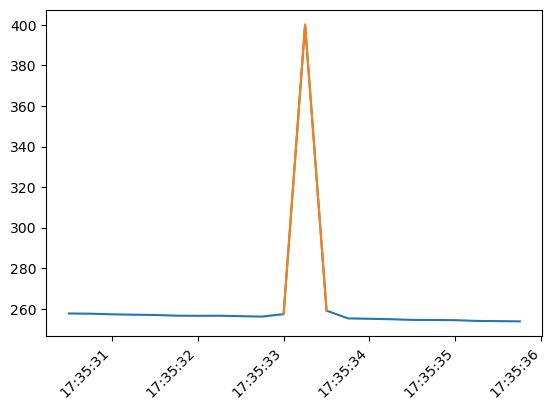

In [83]:
ds=ds_hamp.sel(time=slice('2024-09-12T17:35:30.500000000','2024-09-12T17:35:35.750000000'))#.sel(time=slice('2024-09-14T18:00:55.500000000', '2024-09-14T19:15:55.750000000'))#
#
ds_cut=ds.sel(time=slice('2024-09-12T17:35:33.00000000','2024-09-12T17:35:33.50000000'))
freq=90.0
fig, ax = plt.subplots()
ax.plot(ds.time,ds.TBs.sel(frequency=freq),label='to keep')
ax.plot(ds_cut.time,ds_cut.TBs.sel(frequency=freq),label='to cut')

ax.fill_between(ds.time,ds.TBs.sel(frequency=freq).max(), where=ds.mask_sea_land==0, facecolor='red', alpha=.4,label='land == True')
#ax.fill_between(ds.time,ds.TBs.sel(frequency=freq).max(), where=ds.sel(frequency=freq).mask_amplifier_fault==0, facecolor='purple', alpha=.4,label='amplifier fault == True')
ax.fill_between(ds.time,ds.sel(frequency=freq).TBs.max(), where=np.all(ds.mask_amplifier_fault,axis=1)==0, facecolor='purple', alpha=1,label='amplifier fault == True')

#ax.fill_between(ds.time,ds.IWV.max(), np.all(ds.mask_amplifier_fault,axis=1), facecolor='red', alpha=.4,label='amplifier fault')
#plt.plot(ds.time,~np.any(ds.mask_amplifier_fault,axis=1))
fig.autofmt_xdate(rotation=45)
#plt.legend()

In [22]:
ds_hamp.sel(time=slice('2024-08-11T19:13:15.500000000', '2024-08-11T19:14:55.750000000')).time

<xarray.DataArray 'time' (time: 402)> Size: 3kB
array(['2024-08-11T19:13:15.500000000', '2024-08-11T19:13:15.750000000',
       '2024-08-11T19:13:16.000000000', ..., '2024-08-11T19:14:55.250000000',
       '2024-08-11T19:14:55.500000000', '2024-08-11T19:14:55.750000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 2024-08-11T19:13:15.500000 ... 2024-08...

In [56]:
ds_hamp.sel(frequency=90.0).TBs.max()


<xarray.DataArray 'TBs' ()> Size: 4B
array(83352648., dtype=float32)
Coordinates:
    frequency  float32 4B 90.0

In [61]:
ds_hamp

<xarray.Dataset> Size: 3GB
Dimensions:               (time: 3750412, frequency: 25)
Coordinates:
  * frequency             (frequency) float32 100B 22.24 23.04 ... 188.3 190.8
  * time                  (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... ...
Data variables: (12/14)
    AziAng                (time, frequency) float32 375MB ...
    ElAng                 (time, frequency) float32 375MB ...
    RF                    (time, frequency) float64 750MB ...
    TBs                   (time, frequency) float32 375MB ...
    lat                   (time) float64 30MB ...
    lon                   (time) float64 30MB ...
    ...                    ...
    plane_altitude        (time) float64 30MB ...
    plane_pitch           (time) float64 30MB ...
    plane_roll            (time) float64 30MB ...
    IWV                   (time) float64 30MB ...
    IWP                   (time) float64 30MB ...
    LWP                   (time) float64 30MB ...
Attributes: (12/16)
    Host-PC_Software_Version:     V9.45
    Radiometer_Software_Version:  V9.45
    Radiometer_System:             RPG-HATPRO
    creator_email:                jakob.deutloff@uni-hamburg.de, lukas.kluft@...
    creator_name:                 Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:                  trajectoryProfile
    ...                           ...
    platform:                     HALO
    project:                      ORCESTRA, PERCUSION
    references:                   10.5194/amt-12-1815-2019, 10.5194/essd-13-5...
    summary:                      This dataset contains measurements from the...
    title:                        Radiometer Data from the Halo Microwave Pac...
    version:                      1.0

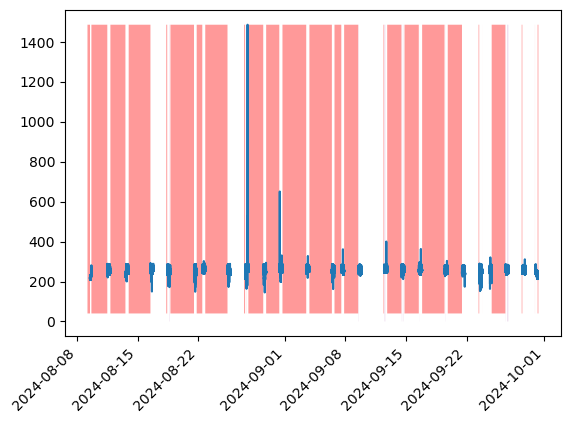

NameError: name 'ds_halo_latest' is not defined

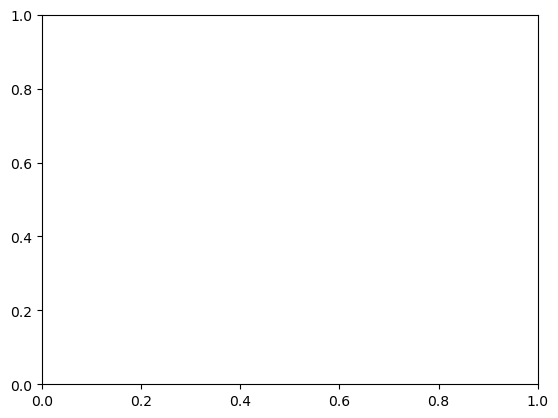

In [6]:

fig, ax = plt.subplots()
ax.plot(ds_hamp.time,ds_hamp.sel(frequency=90.0).TBs)
ax.fill_between(ds_hamp.time,ds_hamp.sel(frequency=90.0).TBs.max(),y2=40, where=ds_hamp.mask_sea_land==0, facecolor='red', alpha=.4,label='land == True')
ax.fill_between(ds_hamp.time,ds_hamp.sel(frequency=90.0).TBs.max(), where=np.all(ds_hamp.mask_amplifier_fault,axis=1)==0, facecolor='purple', alpha=1,label='amplifier fault == True')
#ds_halo_latest
fig.autofmt_xdate(rotation=45)
plt.show()



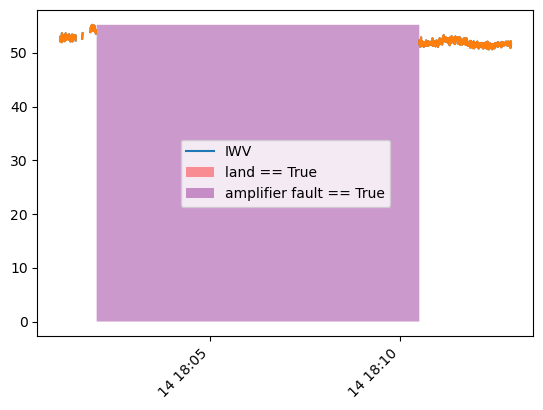

In [42]:

ds=ds_hamp.sel(time=slice('2024-09-14T18:00:55.500000000', '2024-09-14T18:12:55.750000000'))#.sel(time=slice('2024-09-14T18:00:55.500000000', '2024-09-14T19:15:55.750000000'))#
ds_cut=ds.sel(time=slice('2024-09-14T18:00:55.500000000', '2024-09-14T18:12:55.750000000'))
ds_latest=ds_halo_latest.sel(time=slice('2024-09-14T18:00:55.500000000', '2024-09-14T18:12:55.750000000'))
fig, ax = plt.subplots()

ax.plot(ds.time,ds.IWV,label='IWV')
ax.plot(ds_cut.time,ds_cut.IWV)
#ax.plot(ds_latest.time,ds_latest.TBs)
ax.fill_between(ds.time,ds.IWV.max(),y2=40, where=ds.mask_sea_land==0, facecolor='red', alpha=.4,label='land == True')
ax.fill_between(ds.time,ds.IWV.max(), where=np.all(ds_latest.mask_amplifier_fault,axis=1)==0, facecolor='purple', alpha=.4,label='amplifier fault == True')

fig.autofmt_xdate(rotation=45)
#ax.fill_between(ds.time,ds.IWV.max(), np.all(ds.mask_amplifier_fault,axis=1), facecolor='red', alpha=.4,label='amplifier fault')
#plt.plot(ds.time,~np.any(ds.mask_amplifier_fault,axis=1))
plt.legend()


In [ ]:
ds_halo_f.TBs.sel(frequency=chp.get_HAMP_freqs_of('G_band_1side'))

In [46]:
np.sum((a))

<xarray.DataArray 'mask_amplifier_fault' ()> Size: 8B
array(0)

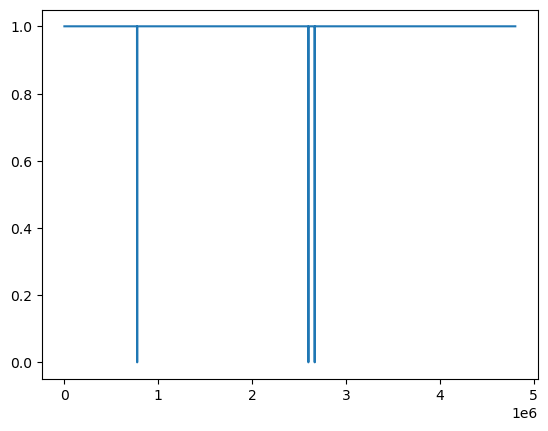

In [52]:
plt.plot((ds_halo_latest.isel(frequency=1).mask_amplifier_fault))

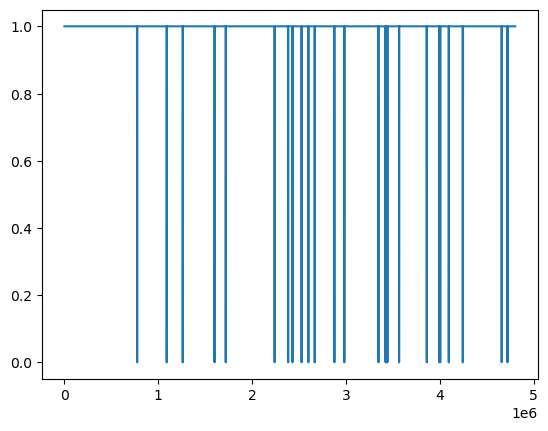

In [54]:
plt.plot(np.all(ds_halo_latest.mask_amplifier_fault,axis=1))